# Neural Networks for Data Science
## End-of-term homework: KV Cache handling and compression

**Name**: Géraldine Valérie Maurer

**Matricola**: 1996887

> ✍ Upload the completed notebook **at least three days** before your expected exam's date on the Google Classroom page. For example, for the **January 12th** session, you should upload it by **January 9th, 23:59 Rome time**.

In [1]:
!pip install -q -U flax jax jaxlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.1/532.1 kB 33.8 MB/s eta 0:00:00


In [2]:
import jax
import jax.numpy as jnp
import jax.random as jrand
import matplotlib.pyplot as plt

### Instructions

1. The homework has two exercises, only the first one is mandatory to access the oral exam.
2. The second exercise is graded (4 points). Without it, the maximum mark for the oral will be 26.
3. Lode requires *exceptional* solutions and orals (top 5%).
4. If you score well on the project but poorly on the oral, the grade can be kept for the entire academic year (up to October 2026).

**IMPORTANT - read carefully before starting**:

> 🟨 *External material*: if you use external material (including AI tools), reference it *explicitly* in the corresponding cell. Copy-paste *is not allowed*.

> 🔵 *Grammar*: please try to be precise and provide nice-to-read descriptions.

> 🟥 *JAX*: the homework must be done _in JAX_ or high-level JAX libraries (Haiku, Flax, equinox, ...). You cannot use libraries that directly solve the core exercise(s). When in doubt, ask.

> 🟪 *Math*: you can use LaTeX in Markdown if you need to write equations or if you need generic math notation.


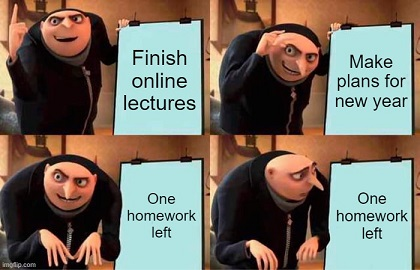

## Warmup: Data loading

For this part, select a dataset that you like, keeping in mind task complexity with respect to the available hardware.

*   You can use any data processing you want (PyTorch data loaders, TensorFlow datasets, Grain, HuggingFace Dataset, ...).
*   Any data type (tabular, images, videos, audio, time-series, graphs, ...) is okay.

A few repositories that you can look at:

1. The catalog of [TensorFlow Datasets](https://www.tensorflow.org/datasets/).
2. The [Kaggle catalog](https://www.kaggle.com/data). For downloading data from Kaggle on Google Colab, you will need to [load your Kaggle authentication token](https://colab.research.google.com/github/corrieann/kaggle/blob/master/kaggle_api_in_colab.ipynb).
3. The [UCI Machine Learning Repository](https://archive.ics.uci.edu/datasets).
4. The [🤗 HuggingFace Datasets](https://huggingface.co/docs/datasets/) repository.

You are not bound to these; any open repository is okay. The choice of dataset will not influence the mark.

✍ **DESCRIPTION OF THE CODE**

*Provide a description of the dataset below (e.g., source, task, bibliographic reference if necessary...), both as text and in the comments of the code. Describe the preprocessing you have applied.*

**TODO**: add description here (1-2 paragraphs).

The dataset I chose for the project is a textual dataset composed of 57607 Chinese poems from the Tang Dynasty and is available at the following GitHub repository: https://github.com/chinese-poetry/chinese-poetry. My goal is to implement a small language model and to train it on Chinese poetry. For this, I will use a decoder-only transformer architecture, with the KV-cache mechanism built into the MHA layers.

**Pre-processing**: Each poem is provided as a list of strings, which were concatenated into a single string during preprocessing. Since the plan was to tokenise at (Chinese) character-level, I looked at the distribution of poem lengths to see how long the maximum sequence length in the transformer would be. Most poems are short (about 64 characters on average), but due to the presence of some outliers with sequence length above 1000, I decided to keep only the poems with length under the 95th percentile of poem lengths. This choice was made to avoid overly long instances to require the `max_seq_len` parameter to be larger than necessary for a vast a majority of poems. After this step, I counted the occurences of each character in the remaining dataset. Since the embedding matrices depend on the vocabulary size, and dropping rare characters with less than 3 occurrences keeps 99.9046% of all character occurrences, I decided to replace these characters with the "unknown token" "`<UNK>`". After this, I encoded the poems, using a "`<BOS>`" (beginning of sequence) token at the start, "`<EOS>`" (end of sequence token) at the end of each poem, filling rare characters in with the "`<UNK>`" token, and using the "`<PAD>`" token to pad the remaining poem's encoding until the maximum sequence length is reached. Finally, the poems were sliced and divided into inputs and targets. The dataset was shuffled randomly and split into a training (90%) and validation (10%) set.

Mounted at /content/drive
Cloning into '/content/drive/MyDrive/chinese-poetry'...
remote: Enumerating objects: 7353, done.
remote: Total 7353 (delta 0), reused 0 (delta 0), pack-reused 7353 (from 1)
Receiving objects: 100% (7353/7353), 236.97 MiB | 10.81 MiB/s, done.
Resolving deltas: 100% (5081/5081), done.
Updating files: 100% (2285/2285), done.


,author,paragraphs,title,id,tags,notes
0,太宗皇帝,"['秦川雄帝宅，函谷壯皇居。', '綺殿千尋起，離宮百雉餘。', '連甍遙接漢，飛觀迥凌虛。...",帝京篇十首 一,3ad6d468-7ff1-4a7b-8b24-a27d70d00ed4,NaN,NaN
1,太宗皇帝,"['巖廊罷機務，崇文聊駐輦。', '玉匣啓龍圖，金繩披鳳篆。', '韋編斷仍續，縹帙舒還卷。...",帝京篇十首 二,13e72581-968b-457f-b381-a3b7d95b8b7c,NaN,NaN
2,太宗皇帝,"['移步出詞林，停輿欣武宴。', '琱弓寫明月，駿馬疑流電。', '驚雁落虛弦，啼猿悲急箭。...",帝京篇十首 三,a7ff247d-a11c-4ca9-a22f-ca420b8c537c,NaN,NaN
3,太宗皇帝,"['鳴笳臨樂館，眺聽歡芳節。', '急管韻朱絃，清歌凝白雪。', '彩鳳肅來儀，玄鶴紛成列。...",帝京篇十首 四,fa374b2b-c196-4362-b4ad-8931fc9a8860,NaN,NaN
4,太宗皇帝,"['芳辰追逸趣，禁苑信多奇。', '橋形通漢上，峰勢接雲危。', '煙霞交隱映，花鳥自參差。...",帝京篇十首 五,86952cb3-b622-4398-a56a-01dd39f6c6ec,NaN,NaN



Number of poems:  57607

First poem:
['秦川雄帝宅，函谷壯皇居。', '綺殿千尋起，離宮百雉餘。', '連甍遙接漢，飛觀迥凌虛。', '雲日隱層闕，風煙出綺疎。']
Poem data type:  <class 'str'>

Poems after conversion:


,paragraphs
0,秦川雄帝宅，函谷壯皇居。綺殿千尋起，離宮百雉餘。連甍遙接漢，飛觀迥凌虛。雲日隱層闕，風煙出綺疎。
1,巖廊罷機務，崇文聊駐輦。玉匣啓龍圖，金繩披鳳篆。韋編斷仍續，縹帙舒還卷。對此乃淹留，欹案觀墳典。
2,移步出詞林，停輿欣武宴。琱弓寫明月，駿馬疑流電。驚雁落虛弦，啼猿悲急箭。閱賞誠多美，於茲乃忘倦。
3,鳴笳臨樂館，眺聽歡芳節。急管韻朱絃，清歌凝白雪。彩鳳肅來儀，玄鶴紛成列。去茲鄭衛聲，雅音方可悅。
4,芳辰追逸趣，禁苑信多奇。橋形通漢上，峰勢接雲危。煙霞交隱映，花鳥自參差。何如肆轍跡？萬里賞瑤池。


The longest poem has 2980 characters
Mean poem length: 63.67424097765897 characters.
Median poem length: 48.0 characters.


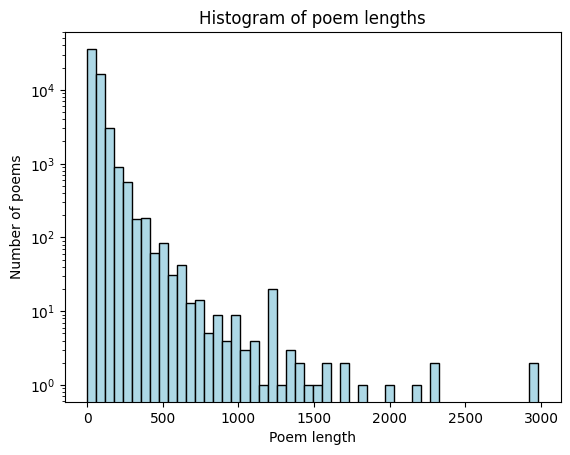


Number of poems after filtering by 95th quantile of poem lengths: 54728/57607

Total number of unique characters: 8351

Most common characters:
[('。', 212137), ('，', 210900), ('不', 24382), ('人', 19970), ('一', 15617), ('山', 15485), ('無', 15319), ('風', 14800), ('日', 14106), ('雲', 12156), ('有', 11886), ('來', 11732), ('何', 11071), ('天', 11050), ('花', 11046), ('上', 10968), ('中', 10861), ('時', 10612), ('春', 10608), ('水', 10526)]

Least common characters:
[('嬃', 1), ('觧', 1), ('甤', 1), ('䱜', 1), ('砯', 1), ('堌', 1), ('淶', 1), ('柂', 1), ('蹳', 1), ('矉', 1), ('褏', 1), ('穭', 1), ('飍', 1), ('袗', 1), ('忺', 1), ('祶', 1), ('璐', 1), ('𡷛', 1), ('枏', 1), ('黲', 1)]

Number of characters that appear less than 3 times in the (filtered) dataset:  2064
Number of characters that appear less than 5 times in the (filtered) dataset:  2688 

mininum frequency = 1 keeps 100.0000% of all character occurrences
mininum frequency = 2 keeps 99.9516% of all character occurrences
mininum frequency = 3 keeps 99.9046% of a

In [3]:
# TODO: Insert all code here.
from pathlib import Path
import os
import json
import re
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

# Set a seed
SEED = 42
np.random.seed(SEED)

# Clone the repository with the dataset and store it in google drive
if not os.path.exists('/content/drive/MyDrive/chinese-poetry'):
    !git clone https://github.com/chinese-poetry/chinese-poetry.git \
        /content/drive/MyDrive/chinese-poetry

# Path in my google drive where the data is saved
repo_path = '/content/drive/MyDrive/chinese-poetry'

# Create a dataframe with the poem dictionaries if it doesn't already exist
# (I am running this code multiple times, so I only retrieve these files once and save them)
if not os.path.exists(repo_path + '/poems.csv'):

  # Get the files that match the file name poet.tang.*.json
  file_paths = [f for f in os.listdir(repo_path + '/全唐诗') if re.match(r'poet\.tang\.\d+\.json', f)]
  poem_dicts = [] # initialize list of dictionaries that will contain the poem data

  for file in file_paths:
    # retrieve the poems from every json file, load it with json and extend the list of poems
    with open(os.path.join(repo_path + '/全唐诗', file), 'r', encoding='utf-8') as f:
      data = json.load(f)
      poem_dicts.extend(data)
  # Save the dataset
  df = pd.DataFrame(poem_dicts)
  df.to_csv(repo_path + '/poems.csv', index=False)

# Load the data
df = pd.read_csv(repo_path + '/poems.csv', encoding='utf-8')

# Extract just the poems
poems = df['paragraphs'].copy()

# Print the dataset
display(df.head())
print('\nNumber of poems: ', len(poems))

# Print the first poem
print('\nFirst poem:')
print(poems[0])
print('Poem data type: ', type(poems[0])) # poems are provided as a list of strings, but the list is a string itself, so we need to convert it

# Turn the poems into pure strings without the list
poems = poems.apply(lambda x: ''.join(eval(x)))
print('\nPoems after conversion:')
display(poems.head())


##### Tokenization
# Convert poem pd.Series to a list
list_of_poems = poems.tolist()

# Print longest poem
poem_lengths =[len(poem) for poem in list_of_poems]
max_length = max(poem_lengths)
max_poem = list_of_poems[list_of_poems.index(max(list_of_poems, key=len))]
print(f'The longest poem has {max_length} characters') # 2980
print(f'Mean poem length: {np.mean(poem_lengths)} characters.') # 64
print(f'Median poem length: {np.median(poem_lengths)} characters.') # 48
#print(max_poem)

# Plot histogram of poem lengths
plt.hist(poem_lengths, bins=50, log=True, color='lightblue', edgecolor='black')
plt.xlabel('Poem length')
plt.ylabel('Number of poems')
plt.title('Histogram of poem lengths')
plt.show()

# Get the 95th quantile of poem lengths, and keep only poems below a max length
# This is done because most poems are short, and the long poems would cause all short ones to require a lot of padding
q = 0.95
max_length = np.quantile(poem_lengths, q)
list_of_poems_cut = [poem for poem in list_of_poems if len(poem) <= max_length]
print(f'\nNumber of poems after filtering by 95th quantile of poem lengths: {len(list_of_poems_cut)}/{len(list_of_poems)}')

# Look at the most common characters
counter = Counter()
for poem in list_of_poems_cut:
    counter.update(poem)
print(f'\nTotal number of unique characters: {len(counter)}')
print('\nMost common characters:')
print(counter.most_common(20))
# Look at the least common tokens
print('\nLeast common characters:')
print(counter.most_common()[-20:])

# Count how many characters only appear once in the entire dataset
min_count = 3
rare_chars = [char for char in counter.keys() if counter[char] < min_count]
rare_chars2 = [char for char in counter.keys() if counter[char] < min_count+2]
print(f'\nNumber of characters that appear less than {min_count} times in the (filtered) dataset: ', len(rare_chars))
print(f'Number of characters that appear less than {min_count+2} times in the (filtered) dataset: ', len(rare_chars2),'\n')

frequencies = counter.values()
total_occurrences = sum(frequencies)
for threshold in [1,2,3,5,10]:
    kept_occurrences = sum(f for f in frequencies if f>=threshold)
    print(f'mininum frequency = {threshold} keeps {kept_occurrences/total_occurrences:.4%} of all character occurrences')

# Initialize token dictionaries
token_to_id = dict()
id_to_token = dict()

# Add '<BOS>' (begin of sequence), '<EOS>' (end of sequence) and '<PAD>' tokens first
# It's best to also add an '<UNK>' (unknown word) token for rare characters that may only appear a few times in the entire dataset
token_to_id = {'<PAD>': 0, '<BOS>': 1, '<EOS>': 2, '<UNK>': 3}
id_to_token = {0: '<PAD>', 1: '<BOS>', 2: '<EOS>', 3: '<UNK>'}
last_id = 4

# Tokenize the text at character level and assign an id to each character
for poem in list_of_poems_cut:
  for char in poem:
    if char not in token_to_id and counter[char]>=3: # keep only characters with frequency of at least 3
      token_to_id[char] = last_id
      id_to_token[last_id] = char
      last_id += 1

print(f'\nNumber of tokens: {len(token_to_id)}')

###### Encoding the poems
poem_encodings = []
for poem in list_of_poems_cut:
  # Add '<BOS>' (1) and '<EOS>' (2) tokens to each poem, and use '<UNK>' (3) whenever the character isn't in the token list
  poem_encodings.append([1] + [token_to_id[char] if char in token_to_id.keys() else 3 for char in poem] + [2]) # Add <BOS> and <EOS> tokens at the start and end

max_seq_length = max([len(poem) for poem in poem_encodings])
print(f'\nMaximum sequence length: {max_seq_length}')

# Pad the poems until they reach the maximum sequence length
for i in range(len(poem_encodings)):
  poem_encodings[i] += [0] * (max_seq_length - len(poem_encodings[i]))

print('\nFirst poem after encoding:')
print(poem_encodings[0])

###### Preparing the dataset
dataset = [(poem[:-1], poem[1:]) for poem in poem_encodings]

# Turn the dataset into a numpy array
dataset = np.array(dataset, dtype=np.int32) # since there are only 6291 tokens, int32 is enough and saves memory
print(f'\nDataset shape: {dataset.shape}')

# Shuffle the dataset
np.random.seed(SEED)
np.random.shuffle(dataset)

# Split into test and validation sets
train_size = int(0.9*len(dataset)) # 90%-10% split between training and validation
train_set = dataset[:train_size]
val_set = dataset[train_size:]
print(f'Training dataset shape: {train_set.shape}')
print(f'Validation dataset shape: {val_set.shape}')

train_inputs, train_targets = train_set[:,0,:], train_set[:,1,:]
val_inputs, val_targets = val_set[:,0,:], val_set[:,1,:]
print(f'Training inputs shape: {train_inputs.shape}, targets shape: {train_targets.shape}')
print(f'Validation inputs shape: {val_inputs.shape}, targets shape: {val_targets.shape}')

# Save these to drive
drive_path = '/content/drive/MyDrive/chinese-poetry'
np.save(drive_path + '/train_inputs.npy', train_inputs)
np.save(drive_path + '/train_targets.npy', train_targets)
np.save(drive_path + '/val_inputs.npy', val_inputs)
np.save(drive_path + '/val_targets.npy', val_targets)


### Exercise 1: KV Cache (mandatory)

**KV caching** is a mechanism implemented in autoregressive transformer models, wherein previous key and value computations are stored and reused when predicting a new token (see book, Chapter 11) and [this blog post](https://magazine.sebastianraschka.com/p/coding-the-kv-cache-in-llms).

> 🟨 Required reading before proceeding: [https://jax-ml.github.io/scaling-book/inference/](https://jax-ml.github.io/scaling-book/inference/).

**TODO**: Write and test a variant of multi-head attention with an internal KV cache mechanism. This is mostly didactical, so you should not concern too much with speed and efficiency (very difficult to achieve in practice).

💡 *Hint*: Start by coding the MHA layer and then add the KV Caching mechanism.

✍ **DESCRIPTION OF THE CODE**

*Provide a description of what you are implementing, both as text and in the comments of the code. Importantly, describe carefully the design of the layer. Train a model with the new layer and show some plots to visualize the training (e.g., loss curves, perplexity, ...) on the data you loaded before.*

**TODO**: add description here (1-2 paragraphs).

### **The transformer model**

For this project, a transformer model named `TangPoetryTransformer` was built and trained on the dataset of Chinese poetry. It relies on four classes:
- `TokenAndPositionEmbedding`: creates the token and position embeddings
- `MultiHeadAttentionWithCache`: implements the multi-head attention mechanism with a `use_cache` flag that, if set to true, enables the KV-cache
- `TransformerBlock`: a single transformer block, structured in this way:
  - Layer normalization 1
  - Multi-head attention (+ residual)
  - Linear layer 1
  - ReLU
  - Linear layer 2
  - Layer normalization 2 (+ residual)
- `TangPoetryTransformer`: uses the above classes and combines them into a unified transformer architecture

#### **Token and Positional Embeddings**

The token and positional embeddings were initialized with the `flax.nnx.Embed` method, using as embedding dimension the hyperparameter $e=$`dim_embed`. The total number of parameters to be learned in this layer are given by the total number of weights in the token lool-up table and the number of weights in the learned positional embedding matrix:

$$
N \cdot e + M \cdot e = e(N+M)
$$

with:
- $N=$ `vocab_size`, number of tokens in the vocabulary
- $M=$ `max_seq_len`, maximum sequence length

#### **Multi-head Attention**

A core component of transformers is the self-attention layer, which is able to capture long-range dependencies and compute relationships between all tokens in an input sequence simultaneously, by using the key-query-value mechanism. In Multi-head Attention (MHA), multiple attention operations run in parallel to model different types of dependencies.

For each attention head $\ell=1,\cdots,h$ of a layer (with $h=$ `num_heads` in the code), the following matrices are defined:

- $W_{k,\ell} \sim (e,k)$
- $W_{v,\ell} \sim (e,\nu)$
- $W_{q,\ell} \sim (e,k)$

Where $k=$ `dim_out_qk` and $\nu=$ `dim_out_v` are hyperparameters.

The embedded tokens are projected using these matrices, giving us the key, value and query tokens. If the input sequence has length $n=$ `seq_length`, the matrix of embedded input tokens $X$ will have shape $(n,e)$. We can write the projections as follows:

- $K_\ell = XW_{k,\ell} \sim (n,k)$
- $V_\ell = XW_{v,\ell} \sim (n,\nu)$
- $Q_\ell = XW_{q,\ell} \sim (n,k)$

The $\ell$-th self-attention layer is defined as

$$
\text{SA}_{\ell}(X) = \text{softmax}\left(\frac{Q_{\ell} K_{\ell}^T}{\sqrt{k}}\right) V_{\ell}
$$

The output of this layer has shape $(n,\nu)$. In the MHA step, the $\text{SA}$ outputs are concatenated and projected using a matrix $W_o \sim (h \nu, o)$, where $o$ is a hyperparameter called `dim_out_o` in the code.

$$
\text{MHA}(X) = [\text{SA}_1(X) \| \ldots \| \text{SA}_h(X)] W_o
$$

**The KV Cache**

The KV Cache is a mechanism used to avoid redundant re-computation of Key and Value matrices for tokens that were already processed. In particular, this is useful in step-by-step computation, where one output token is produced at a time.

In the code, a boolean `use_cache` can trigger the kv-cache mechanism. The buffers `k_cache` and `v_cache` were defined, with shape `(batch_size, num_heads, max_seq_len, head_dim)` where `head_dim` is `dim_out_qk` for the `k_cache` and `dim_out_v` for the `v_cache`. The caches are initialized as `nnx.Cache` objects and wrapped in `nnx.data()` because jax arrays are immutable, but in this way they can be stored as mutable attributes of the class. A `cache_index` is declared to track how many positions have been stored so far. During autoregressive generation, each call to the attention layer computes new queries, keys and values for the newest token(s). If `use_cache` is true, the new keys and values are written into the caches at the position given by the `cache_index` using `jax.lax.dynamic_update_slice`, before the index is incremented by the token sequence length. Then, the layer the entire cache until the current index, including the newly computed keys and values. The causal mask is not needed here because the cache doesn't contain information from future tokens by construction. Meanwhile in the training mode, a lower-triangular mask is needed because all positions are processed simultaneously. This means that each token's key and value are computed only once, the first time it is generated, and reused in every following step for the rest of the sequence. This turns a redundant $O(n^2)$ recomputation across $n$ sequential generation calls into $O(n)$.

A correctness test was executed to verify whether the logits generated with and without cache were close enough, resulting in a maximum absolute distance between logits of 1.07e-06. This confirms that the cache preserves the model's exact computation.

**References**

Below are some resources I consulted when working on the model:

- https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html
- https://magazine.sebastianraschka.com/p/coding-the-kv-cache-in-llms
- https://flax.readthedocs.io/en/latest/api_reference/flax.nnx/variables.html
- https://docs.jax.dev/en/latest/_autosummary/jax.lax.dynamic_update_slice.html

AI assistance (Claude) was used for understanding the jax/flax concepts required for the assignment and for code debugging.

In [4]:
# @title Model Class and Functions

from flax import nnx
import jax.numpy as jnp
from jax import random
import optax
from tqdm import tqdm

class TokenAndPositionEmbedding(nnx.Module):
  """
  Class that creates the token embeddings (look-up matrix) and the positional embeddings,
  using a learned embedding approach for the positional component
  Inputs:
  - vocab_size: size of the vocabulary (number of tokens)
  - max_seq_len: maximum sequence length (max number of tokens in a sequence)
  - dim_embed: embedding dimension
  - rngs: random number generator
  """
  def __init__(self, vocab_size, max_seq_len, dim_embed, rngs: nnx.Rngs):
    # Initialize token and positional embeddings
    self.token_embed = nnx.Embed(vocab_size, dim_embed, rngs=rngs)
    self.pos_embed = nnx.Embed(max_seq_len, dim_embed, rngs=rngs)

  def __call__(self, token_ids, position_offset=0):
    # Compute token embeddings
    embedding_token = self.token_embed(token_ids)
    # Compute positional embeddings
    embedding_position = self.pos_embed(jnp.arange(token_ids.shape[1]) + position_offset)[None,:,:] # for broadcasting over the batches
    # Return combined embedding
    return embedding_token + embedding_position

class MultiHeadAttentionWithCache(nnx.Module):
  """
  Multi-head attention layer with kv cache mechanism
  Inputs:
  - dim_embed: embedding dimension
  - dim_out_qk: number of columns in the query and key projection matrices
  - dim_out_v: number of columns in the value projection matrix
  - dim_out_o: number of columns in the output projection matrix W_o
  - num_heads: number of attention heads
  - max_seq_len: maximum sequence length
  - dropout: dropout rate
  - rngs: random number generator
  """
  def __init__(self, dim_embed, dim_out_qk, dim_out_v, dim_out_o, num_heads, max_seq_len, dropout, rngs):

    # Initialize hyperparameters
    self.num_heads = num_heads
    self.dim_out_qk = dim_out_qk
    self.dim_out_v = dim_out_v
    self.max_seq_len = max_seq_len

    # Define the query, key, value projection matrices
    self.query = nnx.Linear(dim_embed, num_heads * dim_out_qk, rngs=rngs)
    self.key = nnx.Linear(dim_embed, num_heads * dim_out_qk, rngs=rngs)
    self.value = nnx.Linear(dim_embed, num_heads * dim_out_v, rngs=rngs)

    # Output projection matrix
    self.out_proj = nnx.Linear(num_heads * dim_out_v, dim_out_o, rngs=rngs)

    # Define a dropout function
    self.dropout = nnx.Dropout(rate=dropout, rngs=rngs)

    # Initialize the kv cache and cache index
    self.k_cache = None
    self.v_cache = None
    self.cache_index = None

  def init_cache(self, batch_size):
    # The shape of the caches depends on the batch size, number of heads, and the dimension of the key/ value matrices
    # The cache needs to store one key/value vector per past token, per head, per batch element, up to max_seq_len positions,
    # so each cache buffer has shape (batch_size, num_heads, max_seq_len, head_dim)
    # where head_dim is dim_out_qk for the key cache and dim_out_v for the value cache.
    # We want to store the K, V matrices for each head, and for each instance in the batch
    # so we need to add these two dimensions to the cache at the start
    # Both caches are initialised as nnx.Cache() objects, initially storing a tensor of only zeros
    # Since jax arrays are immutable, the cache is wrapped in a nnx.data() function, to store different values in the cache over time
    cache_shape_k = (batch_size, self.num_heads, self.max_seq_len, self.dim_out_qk)
    cache_shape_v = (batch_size, self.num_heads, self.max_seq_len, self.dim_out_v)
    self.k_cache = nnx.data(nnx.Cache(jnp.zeros(cache_shape_k)))
    self.v_cache = nnx.data(nnx.Cache(jnp.zeros(cache_shape_v)))
    self.cache_index = nnx.data(nnx.Cache(jnp.array(0))) # scalar array, 0

  def _split_heads(self, x, head_dim):
    # This function takes the combined output of a linear projection and splits it into separate
    # tensors for each head, which creates a rank-4 tensor that can be stored in the kv cache
    # head_dim is either dim_out_qk or dim_out_v
    batch_size, seq_length, _  = x.shape
    # Separate the heads out of the last dimension
    x = x.reshape(batch_size, seq_length, self.num_heads, head_dim)
    # Swap num_heads and seq_length, to create the tensor shape expected by the cache
    return x.transpose(0,2,1,3)

  def _merge_heads(self, x):
    # Inverse of the _split_heads function, it takes the rank-4 tensor with separate heads
    # and merges them into a single rank-3 tensor, so the attention output into the linear layer out_proj
    batch_size, _, seq_length, head_dim = x.shape
    # Reorder the dimensions to (batch_size, seq_length, num_heads, head_dim)
    x = x.transpose(0,2,1,3)
    # Merge the last two dimensions into one
    return x.reshape(batch_size, seq_length, self.num_heads * head_dim)

  def __call__(self, x, use_cache=False, deterministic=False):
    # Read the batch size and sequence length of the input token sequence
    batch_size, seq_length, _ = x.shape
    # Project input tokens using the query, key, projectio matrices
    # Split the rank-3 tensors into rank-4 tensors with separated heads
    q = self._split_heads(self.query(x), self.dim_out_qk)
    k_new = self._split_heads(self.key(x), self.dim_out_qk)
    v_new = self._split_heads(self.value(x), self.dim_out_v)

    if use_cache:
      # Get the starting index, first emty slot int the cache
      # this depends on how many tokens have already been processed
      start = self.cache_index.get_value()
      # Write the new keys and values into the cache at position start
      # jax.lax.dynamic_update_slice is used because jax arrays are immutable and we can't use normal index assignment
      # For this reason, a new array is created and stored via set_value()
      self.k_cache.set_value(jax.lax.dynamic_update_slice(self.k_cache.get_value(), k_new, (0, 0, start, 0)))
      self.v_cache.set_value(jax.lax.dynamic_update_slice(self.v_cache.get_value(), v_new, (0, 0, start, 0)))
      # Update the cache index by adding the number of tokens added
      self.cache_index.set_value(start + seq_length)

      # Last index of cached tokens
      end = self.cache_index.get_value()
      # Read everything cached so far, including the new tokens
      # Because these will be used for the prediction of the new token(S)
      k = self.k_cache.get_value()[:,:,:end,:]
      v = self.v_cache.get_value()[:,:,:end,:]
      # No causal mask is needed here because the cache only contains past tokens
      mask = None
    else:
      # When cache is not used, we don't recover key/ value tensors computed in the past
      k, v = k_new, v_new
      # Build a lower-triangular boolean mask so that every token can only depend on the previous
      # This enforces causality and avoids data leaking from the future tokens
      mask = jnp.tril(jnp.ones((seq_length, seq_length), dtype=bool))

    # Scaled dot-product attention scores between queries and keys
    # The result is divided by sqrt(dim_out_qk) to keep the dot products from growing too large as dimensionality increases
    scores = jnp.einsum('bhqd,bhkd->bhqk', q, k) / jnp.sqrt(self.dim_out_qk)

    # Apply mask if not None
    # Where the mask is False, the scores are set to a very negative number
    # so that they contribute very little to the softmax scores
    if mask is not None:
      scores = jnp.where(mask, scores, -1e9)

    # Turns attention scores into a probability distribution over the keys
    weights = jax.nn.softmax(scores, axis=-1)

    # Randomly zero out some attention weights during training for regularization
    # When deterministic = True, dropout is disabled
    weights = self.dropout(weights, deterministic=deterministic)

    # Weighted sum of the value vectors using the attention weights between the queries and keys
    attention_out = jnp.einsum('bhqk,bhkd->bhqd', weights, v)

    # Merge all the head's outputs into a single vector per position
    attention_out = self._merge_heads(attention_out)

    # Apply output projection
    attention_out = self.out_proj(attention_out)

    return attention_out


class TransformerBlock(nnx.Module):
  """
  Transformer block
  Inputs:
  - dim_embed: embedding dimension
  - dim_out_qk: number of columns in the query and key projection matrices
  - dim_out_v: number of columns in the value projection matrix
  - dim_out_o: number of columns in the output projection matrix W_o
  - num_heads: number of attention heads
  - max_seq_len: maximum sequence length
  - dropout: dropout rate
  - dim_ff: dimension of the feed-forward layer
  - rngs: random number generator
  """
  def __init__(self, dim_embed, dim_out_qk, dim_out_v, dim_out_o, num_heads, max_seq_len, dropout, dim_ff, rngs: nnx.Rngs):
    # Layer normalization 1
    self.layer_norm1 = nnx.LayerNorm(dim_embed, rngs=rngs)
    # Multi-head self-attention
    self.attention = MultiHeadAttentionWithCache(dim_embed, dim_out_qk, dim_out_v, dim_out_o, num_heads, max_seq_len, dropout, rngs=rngs)
    # Layer normalization 2
    self.layer_norm2 = nnx.LayerNorm(dim_embed, rngs=rngs)
    # Linear layer 1
    self.feed_forward1 = nnx.Linear(dim_embed, dim_ff, rngs=rngs)
    # Linear layer 2
    self.feed_forward2 = nnx.Linear(dim_ff, dim_embed, rngs=rngs)

  def init_cache(self, batch_size):
    # Initialize the cache using the method from MultiHeadAttentionWithCache
    self.attention.init_cache(batch_size)

  def __call__(self, x, use_cache=False, deterministic=False):
    # Normalizae at the start of each block, then MHA + add residual
    x = x + self.attention(self.layer_norm1(x), use_cache=use_cache, deterministic=deterministic)
    # Layer normalization + Linear layer 1 + ReLU activation funxtion + Linear layer 2
    feed_forward = self.feed_forward2(nnx.relu(self.feed_forward1(self.layer_norm2(x))))
    # Add a residual and return the result
    x = x + feed_forward
    return x

class TangPoetryTransformer(nnx.Module):
  """
  Transformer model for tang poetry generation
  Inputs:
  - vocab_size: size of the vocabulary (number of tokens)
  - dim_embed: embedding dimension
  - dim_out_qk: number of columns in the query and key projection matrices
  - dim_out_v: number of columns in the value projection matrix
  - dim_out_o: number of columns in the output projection matrix W_o
  - num_heads: number of attention heads
  - dim_ff: dimension of the feed-forward layer
  - num_layers: number of transformer blocks
  - max_seq_len: maximum sequence length
  - dropout: dropout rate
  - rngs: random number generator
  """
  def __init__(self, vocab_size, dim_embed, dim_out_qk, dim_out_v, dim_out_o,
                num_heads, dim_ff, num_layers, max_seq_len, dropout, rngs: nnx.Rngs):
    self.embedding = TokenAndPositionEmbedding(vocab_size, max_seq_len, dim_embed, rngs=rngs)

    # List of transformer blocks
    self.blocks = nnx.List([TransformerBlock(dim_embed, dim_out_qk, dim_out_v, dim_out_o, num_heads, max_seq_len, dropout, dim_ff, rngs=rngs) for _ in range(num_layers)])
    # Final layer normalization
    self.layer_norm_final = nnx.LayerNorm(dim_embed, rngs=rngs)

  # Function that initializes the cache for every block
  def init_cache(self, batch_size):
    for block in self.blocks:
      block.init_cache(batch_size)

  def __call__(self, token_ids, use_cache=False, deterministic=False, position_offset=0):
    # Create token embeddings + positional embeddings
    # Default offset is 0
    x = self.embedding(token_ids, position_offset)
    # Apply the num_layer transformer blocks
    for block in self.blocks:
      x = block(x, use_cache=use_cache, deterministic=deterministic)
    # Apply the final normalization
    x = self.layer_norm_final(x)

    # Compute the probability distribution over the character vocabulary, for each position in the sequence
    logits = x @ self.embedding.token_embed.embedding.get_value().T
    return logits


# Loss function
def compute_loss(model, inputs, targets, deterministic):
  # Compute the logits
  logits = model(inputs, use_cache=False, deterministic=deterministic)
  # Cross entropy loss
  losses = optax.softmax_cross_entropy_with_integer_labels(logits, targets)
  mask = (targets!=0) # 0 is the pad token ID
  # Compute the average loss per token
  # we mask all the contributions to the loss given by the PAD tokens, because they are uninformative
  masked_loss = jnp.sum(losses*mask) / jnp.sum(mask)
  return masked_loss

# Generator that yields shuffled mini batches of inputs and targets
def batch_iterator(inputs, targets, batch_size, rng_key, shuffle=True):
  n = inputs.shape[0]
  if shuffle:
    # Randomly permutes order of the poems
    perm = np.array(jax.random.permutation(rng_key, n))
    inputs, targets = inputs[perm], targets[perm]
  # Creates batches and yields them
  for start in range(0, n, batch_size):
    end = start + batch_size
    yield inputs[start:end], targets[start:end]

# Evaluation step on one batch, only the loss is computed, with dropout disabled
# No gradients are computed and weights are not updated
@nnx.jit
def eval_step(model, inputs, targets):
  return compute_loss(model, inputs, targets, deterministic=True)

# Evaluates the model over an entire dataset
def evaluate(model, inputs, targets, batch_size):
  total_loss = 0.0
  total_tokens = 0
  # Loops over the batches
  for start in range(0, inputs.shape[0], batch_size):
    end = start + batch_size
    # Retrieve the batches
    x_batch = jnp.array(inputs[start:end])
    y_batch = jnp.array(targets[start:end])
    # Compute the loss on that batch
    loss = eval_step(model, x_batch, y_batch)
    # Count how many real tokens are in the targets, so the loss can be computed correctly
    n_tokens = jnp.sum(y_batch != 0) # 0 is the pad token
    total_loss += float(loss)*float(n_tokens)
    total_tokens += float(n_tokens)
  return total_loss/total_tokens

# Training step on one batch
@nnx.jit
def train_step(model, optimizer, inputs, targets):
  def loss_fn(model):
    return compute_loss(model, inputs, targets, deterministic=False)
  # Compute the loss and the gradients, using the compute_los function from above
  loss, grads = nnx.value_and_grad(loss_fn)(model)
  optimizer.update(model, grads)
  return loss

In [5]:
# @title KV Cache correctness test
import os
import json
import pickle

# Initialize random numebr generator
rngs_test = nnx.Rngs(42)

# Initialize small hyperparameters since this is just for a test
vocab_size_test = 30
dim_embed_test = 16
dim_out_qk_test = 4
dim_out_v_test = 4
dim_out_o_test = dim_embed_test # needs to match dim_embed for the residual addition
num_heads_test = 4
dim_ff_test = 32
num_layers_test = 3
max_seq_len_test = 10
dropout_test = 0.1
batch_test = 2
seq_len_test = 6

# Initialize the small language model
test_model = TangPoetryTransformer(
    vocab_size_test, dim_embed_test, dim_out_qk_test, dim_out_v_test, dim_out_o_test,
    num_heads_test, dim_ff_test, num_layers_test, max_seq_len_test, dropout_test, rngs=rngs_test
)

# Random token id list (random character sequence)
token_ids_test = jax.random.randint(jax.random.PRNGKey(1), (batch_test, seq_len_test), 0, vocab_size_test)

# Case 1: NO CACHE
# dropout is removed with deterministic=True because it sets random attention weights to zero, so it influences the final logits in an unpredictable way
# and then the cached and non-cached cases couldn't be compared
logits_no_cache = test_model(token_ids_test, use_cache=False, deterministic=True)
print("Shape of the logits with no cache:", logits_no_cache.shape)

# Case 2: WITH CACHE
test_model.init_cache(batch_size=batch_test)
outputs = []
for t in range(seq_len_test):
    out_t = test_model(token_ids_test[:, t:t+1], use_cache=True, deterministic=True, position_offset=t)
    outputs.append(out_t)
logits_cache = jnp.concatenate(outputs, axis=1)
print("Shape of the logits with cache:", logits_cache.shape)

# Compare logits between the two versions
max_diff = jnp.max(jnp.abs(logits_no_cache-logits_cache))
print(f"\nMaximum absolute difference between logits : {max_diff:.2e}")

Shape of the logits with no cache: (2, 6, 30)
Shape of the logits with cache: (2, 6, 30)

Maximum absolute difference between logits : 1.07e-06


In [6]:
# @title Training the model

# Training and validation data
drive_path = '/content/drive/MyDrive/chinese-poetry'
train_inputs = np.load(drive_path + '/train_inputs.npy')
train_targets = np.load(drive_path + '/train_targets.npy')
val_inputs = np.load(drive_path + '/val_inputs.npy')
val_targets = np.load(drive_path + '/val_targets.npy')

# Hyperparameters
vocab_size = len(token_to_id)
dim_embed = 128
dim_out_qk = 32
dim_out_v = 32
dim_out_o = dim_embed  # must match for the residual add
num_heads = 4
dim_ff = 512
num_layers = 4
max_seq_len = 153 # maximum sequence length - 1
dropout = 0.1
batch_size = 64
num_epochs = 50

# Intialize random generator
rngs = nnx.Rngs(SEED)
# Initialize the model and optimizer
model = TangPoetryTransformer(vocab_size, dim_embed, dim_out_qk, dim_out_v, dim_out_o,
                               num_heads, dim_ff, num_layers, max_seq_len, dropout, rngs=rngs)
optimizer = nnx.Optimizer(model, optax.adamw(learning_rate=3e-4), wrt=nnx.Param)

# PRNG for key shuffling, to be split in every epoch so there's a new shuffle order every time
master_key = jax.random.PRNGKey(SEED)

# Initialize train and validation loss lists
train_losses, val_losses = [], []

# Directory where checkpoints should be saved
checkpoint_dir = drive_path + '/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True) # doesn't create the directory if it already exists

save_every = 5 # save a full model checkpoint every 5 epochs
best_val_loss = float('inf') # initialize best validation loss

for epoch in tqdm(range(num_epochs)):
  # Split the epoch_key using random.split
  master_key, epoch_key = jax.random.split(master_key)
  epoch_losses = []
  # Iterates over the mini batches, reshuffling happens via epoch_key
  for x_batch, y_batch in batch_iterator(train_inputs, train_targets, batch_size, epoch_key):
    loss = train_step(model, optimizer, jnp.array(x_batch), jnp.array(y_batch))
    epoch_losses.append(loss)
  # Average training loss across all batches in this epoch
  avg_train_loss = float(jnp.mean(jnp.array(epoch_losses)))

  # Evaluate loss on the validation set, using batches to avoid memory overload
  val_loss = evaluate(model, val_inputs, val_targets, batch_size=64)
  train_losses.append(avg_train_loss)
  val_losses.append(val_loss)
  print(f"\nEpoch {epoch+1}/{num_epochs}: train_loss={avg_train_loss:.4f}, val_loss={val_loss:.4f}")

  # Save losses every epoch (cheap, always do this)
  with open(checkpoint_dir + '/losses.json', 'w') as f:
    json.dump({'train_losses': train_losses, 'val_losses': val_losses}, f)
  # Save a periodic checkpoint
  if (epoch+1) % save_every == 0:
    params_state = nnx.state(model, nnx.Param)
    with open(f"{checkpoint_dir}/model_epoch{epoch+1}.pkl", 'wb') as f:
      pickle.dump(params_state, f)
  # Also always keep a copy of the best model by validation loss
  if val_loss < best_val_loss:
    best_val_loss = val_loss
    params_state = nnx.state(model, nnx.Param)
    with open(f"{checkpoint_dir}/model_best.pkl", 'wb') as f:
      pickle.dump(params_state, f)
    print(f"New best val_loss={val_loss:.4f}")

  2%|▏         | 1/50 [00:55<45:38, 55.89s/it]


Epoch 1/50: train_loss=6.1876, val_loss=5.8992
New best val_loss=5.8992


  4%|▍         | 2/50 [01:37<38:13, 47.77s/it]


Epoch 2/50: train_loss=5.7226, val_loss=5.5114
New best val_loss=5.5114


  6%|▌         | 3/50 [02:21<35:51, 45.78s/it]

...


Epoch 48/50: train_loss=3.9256, val_loss=4.3564


 98%|█████████▊| 49/50 [35:29<00:43, 43.06s/it]


Epoch 49/50: train_loss=3.9195, val_loss=4.3598


100%|██████████| 50/50 [36:12<00:00, 43.46s/it]


Epoch 50/50: train_loss=3.9134, val_loss=4.3646


To evaluate the trained model, the loss and perplexity curves were plotted over the 50 epochs.

Moreover, a set of poems was generated using the checkpoint with the lowest validation loss, sampling with the model's own KV cache one character at a time until an `<EOS>` token was produced or `max_seq_len` was reached.

Best validation loss: 4.3501 at epoch 45
Final training loss: 3.9134, final validation loss: 4.3646
Best val perplexity: 77.4865 at epoch 45
Final train perplexity: 50.0671, final val perplexity: 78.6175


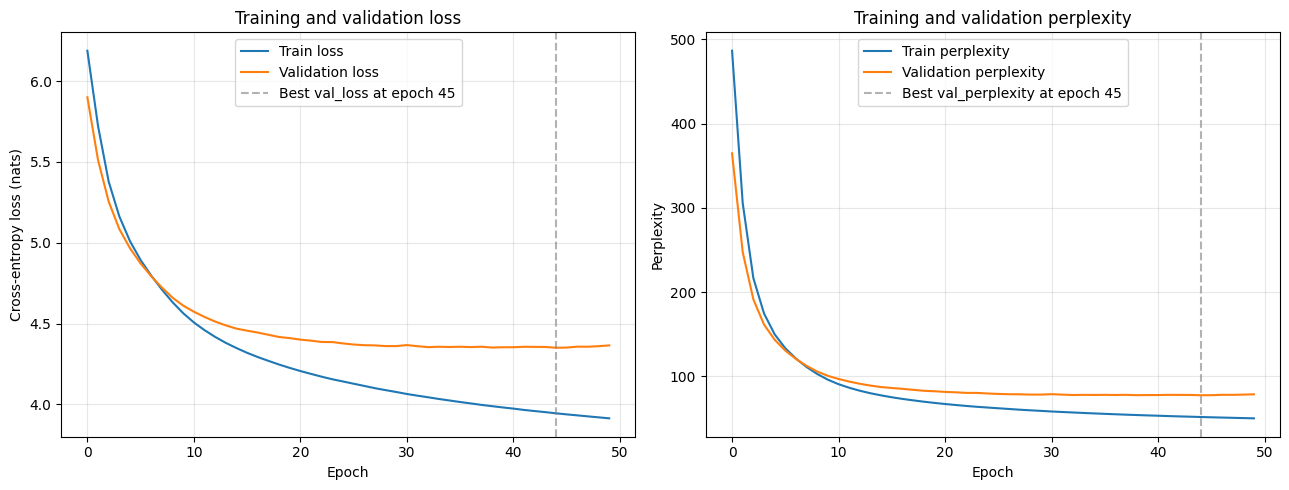


Sampled poems, using the best model (epoch=45), with temperature=0.8

Poem 1: 曾爲勞識越河橋，長內登臨豈可招。酒市只如真祝令，人家堪識世間遙。盧王織女郎恩久，楚女相看在夢遙。從此又須標大道，當時曾見未徵消。

Poem 2: 久別洛陽遊，翩翩臨洛城。故人多寂寞，彊遊獨紛紛。萬里花雲裏，雙蛾淚滿纓。

Poem 3: 天開方朔朔，南陌重秋風。去日朝猶在，無人夜更通。春風分塞上，秋草帶河東。不得還鄉夢，無因免一功。

Poem 4: 室無外兮不能飲，神虛之中千古無。不是虛兮暮與巫山與人乎，路不見君心。（見《宋高僧傳歌詩》卷十九《羅道草類》）。

Poem 5: 林棲不可望，夏漏忽相悲。羣閣多逸翮，儂家在重脂。碧雲生綠水，紅日落紅肌。唯有能歸去，悠悠方外期。

Poem 6: 太平南風慘，難與長安客。旦夕降那歸，聞君成楚矣。乘流竟何處，志氣方晦跡。白雲抱幽慮，寂寂苔漫積。開理俱冥冥，氛氳換衣服。幽人感神和，萬象無窮極。又疑白日老，更憶青山曲。西閣鬱嵯峨，寥落空林雪。

Poem 7: 春山長老不知音，更說君知出眼心。雙鬢已成如別恨，一年功是不堪斟。

Poem 8: 近裏山沈處，新天岫色微。溪花人語古，林鳥鳥啼稀。靜室人難見，閑門鳥自歸。沈沈何處說，向晚可同歸。

Poem 9: 日晴山色斜，夜靜寺燈火。古寺青苔時，高簾青草色。清餘殘果落，軟的滿牀眼。兒女無言語，學雞堪贈燕。

Poem 10: 家經早過日，行子勸人耕。八十居家事，興今老帝京。


Sampled poems, using the best model (epoch=45), with temperature=0.01

Poem 1: 一片青山路，千年白日程。不知今日事，何處是君情。

Poem 2: 一片青山路，千年白日程。不知今日事，何處是君情。

Poem 3: 一片青山路，千年白日程。不知今日事，何處是君行？



In [8]:
# @title Evaluation of the results and poem generation
import json
# Read the checkpoint losses
checkpoint_dir = '/content/drive/MyDrive/chinese-poetry/checkpoints'
with open(checkpoint_dir + '/losses.json', 'r') as f:
  loss_history = json.load(f)
# Training and validation losses
train_losses = loss_history['train_losses']
val_losses = loss_history['val_losses']

# Index of the epoch with the best validation loss
best_epoch_idx = int(np.argmin(val_losses))
print(f"Best validation loss: {val_losses[best_epoch_idx]:.4f} at epoch {best_epoch_idx+1}")
print(f"Final training loss: {train_losses[-1]:.4f}, final validation loss: {val_losses[-1]:.4f}")

# Perplexity curves
train_perplexities = [float(np.exp(l)) for l in train_losses]
val_perplexities = [float(np.exp(l)) for l in val_losses]
# Print best train and validation perplexities
print(f"Best val perplexity: {min(val_perplexities):.4f} at epoch {int(np.argmin(val_perplexities))+1}")
print(f"Final train perplexity: {train_perplexities[-1]:.4f}, final val perplexity: {val_perplexities[-1]:.4f}")

best_epoch_idx = int(np.argmin(val_losses))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Loss curves
axes[0].plot(train_losses, label='Train loss')
axes[0].plot(val_losses, label='Validation loss')
axes[0].axvline(best_epoch_idx, color='gray', linestyle='--', alpha=0.6, label=f'Best val_loss at epoch {best_epoch_idx+1}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss (nats)')
axes[0].set_title('Training and validation loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Perplexity curves
axes[1].plot(train_perplexities, label='Train perplexity')
axes[1].plot(val_perplexities, label='Validation perplexity')
axes[1].axvline(best_epoch_idx, color='gray', linestyle='--', alpha=0.6, label=f'Best val_perplexity at epoch {best_epoch_idx+1}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Training and validation perplexity')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Re-instantiate a fresh model with the SAME architecture hyperparameters
rngs_gen = nnx.Rngs(SEED)
# Hyperparameters (same as before)
vocab_size = len(token_to_id)
dim_embed = 128
dim_out_qk = 32
dim_out_v = 32
dim_out_o = dim_embed  # must match for the residual add
num_heads = 4
dim_ff = 512
num_layers = 4
max_seq_len = 153 # maximum sequence length-1
dropout = 0.1
batch_size = 64
num_epochs = 200
best_model = TangPoetryTransformer(vocab_size, dim_embed, dim_out_qk, dim_out_v, dim_out_o,
                                     num_heads, dim_ff, num_layers, max_seq_len, dropout, rngs=rngs_gen)

with open(checkpoint_dir + '/model_best.pkl', 'rb') as f:
  best_params = pickle.load(f)
nnx.update(best_model, best_params) # update the new model with the best parameters

# Create a function to generate poems
def generate_poem(model, id_to_token, max_seq_len, rng_key, temperature=1.0):
  bos_id = 1 # beginning of sequence ID
  eos_id = 2 # end of sequence ID

  # Initialize the cache with batch size equal to 1
  model.init_cache(batch_size=1)
  # Initialize the list of generated ids, and the current token ID
  generated_ids = [bos_id]
  current_token = jnp.array([[bos_id]])

  # Generate tokens for each new position
  for position in range(max_seq_len-1):
    # compute the logits using cache, and no dropout
    logits = model(current_token, use_cache=True, deterministic=True, position_offset=position)
    next_logits = logits[0,-1,:]/temperature
    # split a sample_key with random.split
    rng_key, sample_key = jax.random.split(rng_key)
    # Sample the next ID from the distribution given by the logits
    next_id = int(jax.random.categorical(sample_key, next_logits))
    generated_ids.append(next_id)
    # stop generation if the EOS ID is reached
    if next_id == eos_id:
      break
    # update current token
    current_token = jnp.array([[next_id]])

  special_ids = {0,1,2} # PAD, BOS, EOS token IDs
  # Map token IDs to characters
  chars = [id_to_token[ids] for ids in generated_ids if ids not in special_ids]
  return ''.join(chars)

# Print some poems
print("\nSampled poems, using the best model (epoch=45), with temperature=0.8\n")
for i in range(10):
    poem = generate_poem(best_model, id_to_token, max_seq_len, rng_key=jax.random.PRNGKey(i), temperature=0.8)
    print(f"Poem {i+1}: {poem}\n")

print("\nSampled poems, using the best model (epoch=45), with temperature=0.01\n")
for i in range(3):
    poem = generate_poem(best_model, id_to_token, max_seq_len, rng_key=jax.random.PRNGKey(i+100), temperature=0.01)
    print(f"Poem {i+1}: {poem}\n")

#### Translations

Below are the Claude-generated translations of the poems. We can observe that the model learned the appropriate structure and vocabulary of the poems, but occasionally struggles with consistency across lines.

**Poem 1**:

曾爲勞識越河橋，長內登臨豈可招。酒市只如真祝令，人家堪識世間遙。盧王織女郎恩久，楚女相看在夢遙。從此又須標大道，當時曾見未徵消。

**Translation**:
```
Once, for toilsome duties, I crossed the bridge over the Yue river;
long within, how could such an ascent ever be summoned back?
The wine-market is just like a true magistrate's decree;
common households can sense how distant the world is.
The Weaving Maiden's kindness to Lu-Wang has lasted long;
the woman of Chu gazes back, met only in a distant dream.
From here I must again mark out the great road —
what I once saw at that time has still not faded away.
```

**Poem 2**:

久別洛陽遊，翩翩臨洛城。故人多寂寞，彊遊獨紛紛。萬里花雲裏，雙蛾淚滿纓。

**Translation**:
```
Long parted from my travels in Luoyang,
gracefully now I approach the city of Luo.
Old friends are, for the most part, lonely;
forced onward in travel, I alone am troubled.
Ten thousand miles, within clouds of flowers;
twin moth-brows, tears filling my sash.
```

**Poem 3**:

天開方朔朔，南陌重秋風。去日朝猶在，無人夜更通。春風分塞上，秋草帶河東。不得還鄉夢，無因免一功。

**Translation**:
```
Heaven opens, and Dongfang Shuo appears once more;
the southern lane meets autumn wind again.
The departing sun's morning light still lingers;
at night, no one passes through.
Spring wind divides along the frontier;
autumn grass lines the eastern riverbank.
I cannot even return home in dream —
there is no cause to be spared this one task.
```

**Poem 4**:

室無外兮不能飲，神虛之中千古無。不是虛兮暮與巫山與人乎，路不見君心。（見《宋高僧傳歌詩》卷十九《羅道草類》）。

**Translation**:
```
Within the chamber, with nothing outside, I cannot drink;
amid empty spirit, nothing has existed through the ages.
Is it not emptiness — at dusk, with Wushan, with another person? —
the road does not reveal your heart.
(Cited in: Biographies of Eminent Monks of the Song, Poetic Verses,
vol. 19, "Category of Luo Dao Grasses.")
```
*Note: the trailing citation is itself model-generated*

**Poem 5**:

林棲不可望，夏漏忽相悲。羣閣多逸翮，儂家在重脂。碧雲生綠水，紅日落紅肌。唯有能歸去，悠悠方外期。

**Translation**:
```
The forest dwelling cannot be gazed upon;
summer's water-clock suddenly brings mutual sorrow.
The clustered pavilions hold such carefree wings;
my home lies amid layered rouge.
Jade-green clouds rise from the green water;
the red sun sets upon reddened flesh.
Only the ability to return remains —
vast and boundless, a meeting beyond this world.
```

**Poem 6**:

太平南風慘，難與長安客。旦夕降那歸，聞君成楚矣。乘流竟何處，志氣方晦跡。白雲抱幽慮，寂寂苔漫積。開理俱冥冥，氛氳換衣服。幽人感神和，萬象無窮極。又疑白日老，更憶青山曲。西閣鬱嵯峨，寥落空林雪。

**Translation**:
```
In great peace, the south wind still turns bleak;
hard to remain a guest in Chang'an.
Morning and evening, descending — where shall I return?
I hear that you have become a man of Chu.
Riding the current, where shall I end up?
My resolve now hides its own trace.
White clouds embrace hidden worries;
silent, moss piles ever deeper.
Understanding unfolds in obscurity;
mist and vapor exchange my very clothes.
The recluse feels harmony with the spirit;
the ten thousand forms are without end.
Again I suspect the bright sun itself grows old;
further still I recall the winding green mountains.
The western tower rises lofty and rugged;
desolate, snow fills the empty forest.
```

**Poem 7**:

春山長老不知音，更說君知出眼心。雙鬢已成如別恨，一年功是不堪斟。

**Translation**:
```
The old elder of the spring mountains has no kindred spirit;
further he says you understand what shows in the eyes and heart.
My greying temples have already become like the pain of parting;
a year's labor is unbearable even to measure out.
```

**Poem 8**:

近裏山沈處，新天岫色微。溪花人語古，林鳥鳥啼稀。靜室人難見，閑門鳥自歸。沈沈何處說，向晚可同歸。

**Translation**:
```
Nearby, where the mountain sinks low;
the new sky's peaks show a faint color.
Stream-side flowers, human speech ancient;
forest birds, their song grown sparse.
In the quiet chamber, one is hard to find;
at the idle gate, birds return by themselves.
Heavy and still — where can this be spoken?
Toward evening, perhaps we may return together.
```

**Poem 9**:

日晴山色斜，夜靜寺燈火。古寺青苔時，高簾青草色。清餘殘果落，軟的滿牀眼。兒女無言語，學雞堪贈燕。

**Translation**:
```
Sun bright, mountain colors slant;
night still, temple lamp-fires glow.
When the old temple's green moss appears,
the tall curtain takes on the color of green grass.
Clear remains of withered fruit fall away;
soft [fragment — does not fully parse] fills the bed.
The children speak no words at all;
learning from the rooster, fit to gift to the swallow.
```

**Poem 10**:

家經早過日，行子勸人耕。八十居家事，興今老帝京。

**Translation**:
```
My family's classics passed their days early on;
the traveling son urges others to plow.
At eighty, dwelling still on household matters;
flourishing now, growing old in the imperial capital.
```

**Poems 11-13** (T=0.01)

一片青山路，千年白日程。不知今日事，何處是君情。
一片青山路，千年白日程。不知今日事，何處是君情。
一片青山路，千年白日程。不知今日事，何處是君行？

**Translation**:
```
A single stretch of green mountain road;
a thousand years' journey beneath the bright sun.
I do not know today's affairs —
where does your feeling lie? / where are you headed?
```

### Exercise 2: KV Cache compression (4 points)

**KV cache compression** algorithms try to dinamically reduce the size of the KV cache by, e.g., removing key/value pairs, or compressing them to a reduced set of tokens. See [this paper](https://arxiv.org/abs/2406.11430) for an introduction, and the [kvpress](https://github.com/NVIDIA/kvpress) library from NVIDIA for practical implementations (in PyTorch).

**TODO**: Reimplement (and test) one of the methods from the KVPress library (e.g., `KnormPress`).

✍ **DESCRIPTION OF THE CODE**

*Provide a description of what you are implementing, both as text and in the comments of the code. When feasible, show some statistics on the layer (e.g. on the resulting size of the KV cache and/or which tokens tend to be selected for exclusion).*

**TODO**: add description here (1-2 paragraphs).

For the KV Compression, the KnormPress method was reproduced. The method is based on the finding of the correlation between high attention scores and the L2 norms of the keys. In the code, the negative L2 norm of every key is computed, and only the `target_size` highest-scoring keys are kept (lowest norms). A `MultiHeadAttentionWithCompressedKVCache` class is created, as an extention of the previous MHA class, and it includes the `compress_cache(target_size)` method. If a cache exceeds the `target_size`, they keys are scored based on their L2 norms, and only the most relevant (with the highest negative norms) keys and their associated values, are written into a new cache buffer. The `cache_index` is adjusted accordingly.

The KV compression was tested on a toy layer. The cache was initially filled with 12 tokens and then compressed to six, with only the keys with lower norms retained. Generation continued correctly after the compression.

**References**:
- https://arxiv.org/abs/2406.11430
- https://github.com/NVIDIA/kvpress

In [9]:
# @title KV Cache Compression
# TODO: Your code here.
class MultiHeadAttentionWithCompressedKVCache(MultiHeadAttentionWithCache):
  """
  This class is an extension of the MultiHeadAttentionWithCache class from point 1
  It implements a compression mechanism that follows KnormPress
  The cache is reduced to a target_size, so that the key/value pairs with the smallest L2 norm are kept while the rest is dropped
  This way, the cache's memory only occupies O(target_size)
  """

  def compress_cache(self, target_size):
    # Function that compresses the cache down to target_size positions, keeping the keys with the lowest norm and the corresponding values
    # Compression is applied independently for each batch element and head because the cache stores a separate dimension for each

    # see how long the cache is
    end = int(self.cache_index.get_value())
    if end<=target_size:
      # if it has not exceeded the target size yet, there's nothing to compress
      return None

    # Read the K and V caches
    k = self.k_cache.get_value()[:, :, :end, :]  # shaep = (batch_size, num_heads, end, dim_out_qk)
    v = self.v_cache.get_value()[:, :, :end, :]  # shape = (batch_size, num_heads, end, dim_out_v)

    # Compute the negative L2 norm of the keys (we want to keep elements with small norms, which are less negative)
    scores = -jnp.linalg.norm(k, axis=-1)

    # Select the positions with highest norm scores (least negative) independently for each batch element and head
    _, top_indices = jax.lax.top_k(scores, k=target_size)  # shape = (batch_size, num_heads, target_size)

    # Sort indexes (easier to debug if needed)
    top_indices = jnp.sort(top_indices, axis=-1)

    # Gather the surviving keys/values along the sequence axis
    top_indeces_augm = top_indices[..., None]  # shape = (batch_size, num_heads, target_size, 1)
    compressed_k = jnp.take_along_axis(k, top_indeces_augm, axis=2)
    compressed_v = jnp.take_along_axis(v, top_indeces_augm, axis=2)

    # Write the compressed keys and values into new cache buffers
    # Use the shape of the old one, fill it with the compressed kv's
    new_k_cache = jax.lax.dynamic_update_slice(jnp.zeros_like(self.k_cache.get_value()), compressed_k, (0, 0, 0, 0))
    new_v_cache = jax.lax.dynamic_update_slice(jnp.zeros_like(self.v_cache.get_value()), compressed_v, (0, 0, 0, 0))

    # Update the cache
    self.k_cache.set_value(new_k_cache)
    self.v_cache.set_value(new_v_cache)
    # Update the cache_index to target_size
    self.cache_index.set_value(jnp.array(target_size))

    return top_indices

# Verify that the compression works correctly on every layer
rngs = nnx.Rngs(42)
dim_embed=16
dim_out_qk = 4
dim_out_v = 4
dim_out_o = dim_embed
num_heads = 2
max_seq_len = 20
batch = 1

# Attention layer
attention = MultiHeadAttentionWithCompressedKVCache(dim_embed, dim_out_qk, dim_out_v, dim_out_o, num_heads, max_seq_len,dropout=0.0, rngs=rngs)
attention.init_cache(batch_size=batch)

# Simulate 12 generation steps, fill the cache with 12 tokens keys and values
x_full = jax.random.normal(jax.random.PRNGKey(1), (batch, 12, dim_embed))
for t in range(12):
  _ = attention(x_full[:, t:t+1, :], use_cache=True, deterministic=True)
# Print the cache index and key norms per head before compression
print("Cache index before compression:", int(attention.cache_index.get_value()))
k_before = attention.k_cache.get_value()[:, :, :12, :]
norms_before = jnp.linalg.norm(k_before, axis=-1)
print("Key norms before compression (per head):")
print(norms_before[0])

# Compress down to 6 tokens
kept_indices = attention.compress_cache(target_size=6)
print("\nCache index after compression:", int(attention.cache_index.get_value()))
print("Kept original positions (per head):")
print(kept_indices[0])
# print the key norms after the compression
k_after = attention.k_cache.get_value()[:, :, :6, :]
norms_after = jnp.linalg.norm(k_after, axis=-1)
print("\nKey norms after compression (per head):")
print(norms_after[0])

# Verify generation continues correctly after compression
print("\nContinuing generation after compression:")
for t in range(12, 15):
  x_t = jax.random.normal(jax.random.PRNGKey(t), (batch, 1, dim_embed))
  out = attention(x_t, use_cache=True, deterministic=True)
  print(f"Step {t}: cache_index after = {int(attention.cache_index.get_value())}, output shape = {out.shape}")

Cache index before compression: 12
Key norms before compression (per head):
[[1.355749   1.3587419  3.1631742  2.2887034  2.9684074  0.63490194
  0.6936238  1.4810854  4.7515063  1.4810313  2.3731952  1.6426657 ]
 [1.5511321  1.0211813  1.6203508  5.168456   1.4304886  2.741899
  2.8322902  1.0304165  0.8710762  3.100568   2.5642579  2.2529936 ]]

Cache index after compression: 6
Kept original positions (per head):
[[0 1 5 6 7 9]
 [0 1 2 4 7 8]]

Key norms after compression (per head):
[[1.355749   1.3587419  0.63490194 0.6936238  1.4810854  1.4810313 ]
 [1.5511321  1.0211813  1.6203508  1.4304886  1.0304165  0.8710762 ]]

Continuing generation after compression:
Step 12: cache_index after = 7, output shape = (1, 1, 16)
Step 13: cache_index after = 8, output shape = (1, 1, 16)
Step 14: cache_index after = 9, output shape = (1, 1, 16)


### Final checklist

1. Carefully check all textual descriptions and the code. Insert comments when needed. <ins>Check for TODO to see if you missed anything.</ins>
2. Run everything one final time. *Please do not send me notebooks with errors or cells that are not working.*
3. Send the completed notebook following the instructions on top.